In [ ]:
#23070521078, Krishna Wairagade
# House price prediction using deep feedforward Network
# Problem statement - Predict house prices using a deep feedforward Neural Network on Kaggle housing dataset.
# Activities to perform - 1) Data preprocessing and normalization.
#                         2) Designing deep feedforward Neural Network architecture
#                         3) Prediction rate - evaluate using MAE, MSE, RMSE.
#                         4) Explore different number of layers to improve the performance of the architecture.

In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
# Upload dataset
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('train.csv')

df.head()

Saving train.csv to train (1).csv


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Data Preprocessing
# Remove ID column
df.drop("Id", axis=1, inplace=True)

# Separate target
y = df["SalePrice"]
X = df.drop("SalePrice", axis=1)

# Convert categorical variables
X = pd.get_dummies(X)

# Fill missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

print("Shape:", X.shape)

Shape: (1460, 287)


In [ ]:
# Normalization
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
# Train, Test, Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1168, 287)
(292, 287)


In [ ]:
#Build Deep Feedforward Neural Network (3 Hidden Layers)
model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(128, activation='relu'))

model.add(Dense(64, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,945 (449.00 KB)

 Trainable params: 114,945 (449.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 39139377152.0000 - mae: 181508.6875 - val_loss: 37813927936.0000 - val_mae: 181034.8281
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 39006986240.0000 - mae: 181223.7812 - val_loss: 37446868992.0000 - val_mae: 180249.5625
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37900120064.0000 - mae: 178982.3906 - val_loss: 35235684352.0000 - val_mae: 175494.8594
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33394585600.0000 - mae: 169016.7188 - val_loss: 28092401664.0000 - val_mae: 158497.8594
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22316386304.0000 - mae: 139861.3281 - val_loss: 15975132160.0000 - val_mae: 117325.7031
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11509312512.0000 - mae: 94076.5547 - val_loss: 10230880256.0000 - val_mae: 86079.8125
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7836830208.0000 - mae: 75694.8750 - val_loss: 8199969280.0000

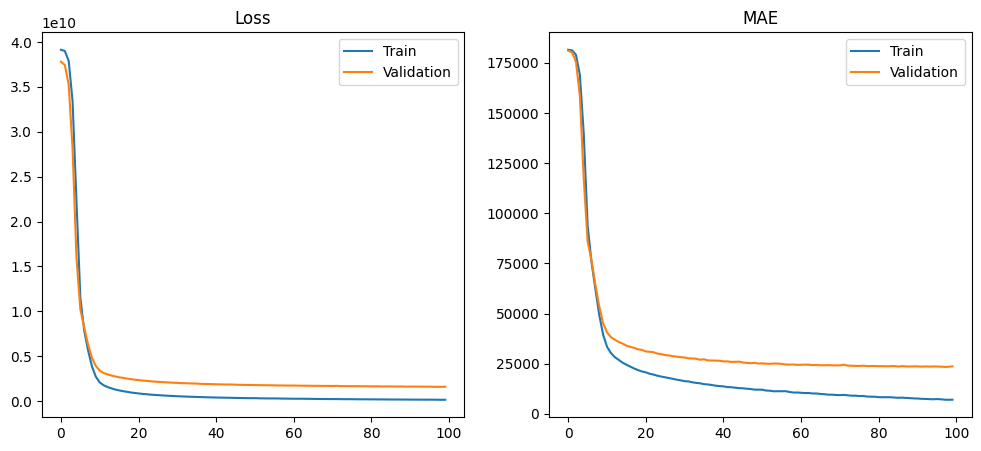

In [ ]:
# Plot Trainging Graphs
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Validation')
plt.title("MAE")
plt.legend()

plt.show()

In [ ]:
# Predictions
predictions = model.predict(X_test)

predictions = predictions.flatten()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [ ]:
# Performance Evaluation
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)

Mean Absolute Error : 23608.58984375
Mean Squared Error  : 1502391936.0
Root Mean Squared Error : 38760.70092245495


In [ ]:
# Compare Actual vs Predicted
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results.head(20)

,Actual,Predicted
0,154500,161685.656250
1,325000,345511.125000
2,115000,107939.578125
3,159000,160360.281250
4,315500,356811.343750
5,75500,87427.468750
6,311500,228985.984375
7,146000,137669.578125
8,84500,86545.687500
9,135500,138452.312500


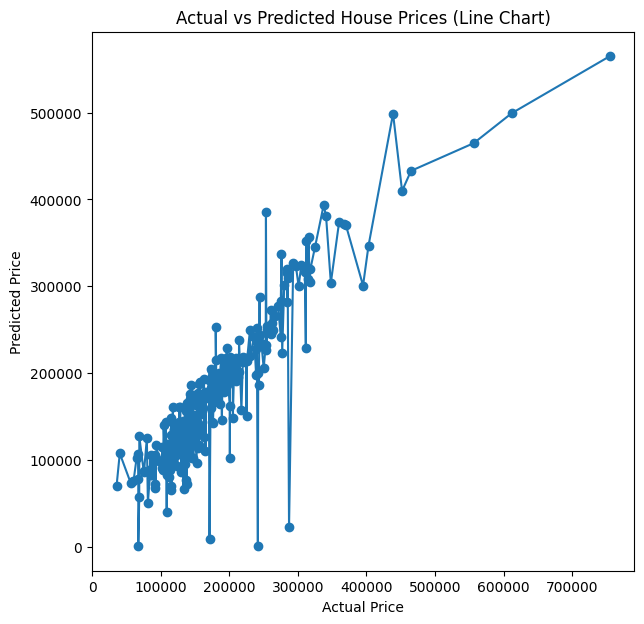

In [ ]:
# Line Chart
plt.figure(figsize=(7,7))

# Sort the values for a better line chart visualization
sorted_indices = np.argsort(y_test)
plt.plot(y_test.iloc[sorted_indices], predictions[sorted_indices], marker='o', linestyle='-')

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices (Line Chart)")

plt.show()

In [ ]:
# Experiment with a Deeper Network (5 Hidden Layers)
deep_model = Sequential()

deep_model.add(Dense(512, activation='relu', input_shape=(X_train.shape[1],)))

deep_model.add(Dense(256, activation='relu'))

deep_model.add(Dense(128, activation='relu'))

deep_model.add(Dense(64, activation='relu'))

deep_model.add(Dense(32, activation='relu'))

deep_model.add(Dense(1))

deep_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,049 (1.23 MB)

 Trainable params: 322,049 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Deeper Model
history2 = deep_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 39102697472.0000 - mae: 181422.0938 - val_loss: 37569843200.0000 - val_mae: 180451.6250
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 35194458112.0000 - mae: 172723.3125 - val_loss: 23448346624.0000 - val_mae: 144831.2656
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10666833920.0000 - mae: 88892.8750 - val_loss: 5168658944.0000 - val_mae: 57875.3047
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2258875136.0000 - mae: 34785.1875 - val_loss: 2608491264.0000 - val_mae: 34781.9453
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1294396928.0000 - mae: 25090.6348 - val_loss: 2286480896.0000 - val_mae: 31708.0703
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 958930048.0000 - mae: 21538.6465 - val_loss: 2040454144.0000 - val_mae: 29585.1035
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 772940992.0000 - mae: 19231.6094 - val_loss: 1962984832.0000 - val_mae: 286

In [ ]:
# Evaluate the Deeper Model
pred2 = deep_model.predict(X_test)

pred2 = pred2.flatten()

mae2 = mean_absolute_error(y_test, pred2)

mse2 = mean_squared_error(y_test, pred2)

rmse2 = np.sqrt(mse2)

print("Deep Network Results")

print("MAE :", mae2)

print("MSE :", mse2)

print("RMSE :", rmse2)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Deep Network Results
MAE : 20134.400390625
MSE : 1034759232.0
RMSE : 32167.673711351898
